# Week 13 Assignment #8: Understanding Mushrooms!
Student: Daniel Foulen

Class: IS 362

Date: 4/28/2026

## Background

This notebook preprocesses the UCI Mushroom dataset in preparation for downstream classification with scikit-learn. 

The dataset describes physical characteristics of gilled mushrooms, things like odor, cap color, bruising, and gill size, all labeling each sample as either edible or poisonous.

This notebook explores the data and shapes it for readability and understanding before it can go through a machine learning pipeline. 

Context is everything (I'm not trying to have a good idea today and then not understand anything when I'm debugging later).

## Applications

**Why encode categorical data as numeric values?**

scikit-learn's algorithms operate on numbers. 

When a column contains strings like `"p"` or `"e"`, the library has no way to compute distances, dot products, or splits, it's just going to give an error. 

Converting each category to an integer (or a set of binary columns) is a required preprocessing step that makes my life easier.

**Why do exploratory analysis before modeling?**

Before committing to a feature set, it's worth looking at distributions and relationships. 

A feature that is heavily imbalanced, or one that has a near-perfect visual separation between classes, tells you the first might not add signal, while the second might be doing most of the heavy lifting. 

EDA helps me build intuition so the model's results aren't undecipherable when I look at this tomorrow.

## Step 1: Import Libraries

I'm pulling in four libraries:
- **pandas**: for dataframes
- **matplotlib.pyplot**: plotting
- **seaborn**: for clean statistical charts (countplots, stripplots)
- **ucimlrepo**: UC Irvine's ML Repository client; lets me fetch datasets by ID without downloading any files manually

In [1]:
!pip3 install -U ucimlrepo 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

## Step 2: Load the Dataset

`fetch_ucirepo(id=73)` pulls the UCI Mushroom dataset directly. It returns an object with two components:
- **X**: the feature matrix (one row per mushroom, one column per physical characteristic)
- **y**: the target vector (a single column: `class`, either `"e"` for edible or `"p"` for poisonous)

I join them into a single DataFrame so the target label travels with its features. This makes subsetting, renaming, and encoding easier to reason about in one place.

In [2]:
# fetch dataset (id=73 is the UCI Mushroom dataset)
mushroom = fetch_ucirepo(id=73)

X = mushroom.data.features   # physical characteristics
y = mushroom.data.targets    # edible / poisonous label

# combine into one DataFrame
df = pd.concat([X, y], axis=1)

print("Shape:", df.shape)
df.head()

Shape: (8124, 23)


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


## Step 3: Subset the Columns

The full dataset has 22 feature columns. For this assignment I'm keeping just three:

- **class -> edibility**: the target label we'd want to predict: edible (e) or poisonous (p)
- **odor**: required by the assignment; also widely cited as one of the strongest predictors in this dataset
- **bruises**: a simple binary column (mushroom has bruises or doesn't): worth checking as a second candidate predictor

Narrowing to three columns makes the encoding and visualization steps easier to follow step by step.

In [3]:
# keep only the three columns we care about
# note: ucimlrepo names the target column 'poisonous', not 'class'
df = df[['poisonous', 'odor', 'bruises']].copy()

# rename for clarity
df.columns = ['edibility', 'odor', 'bruises']

df.head()

,edibility,odor,bruises
0,p,p,t
1,e,a,t
2,e,l,t
3,p,p,t
4,e,n,f


## Step 4: Encode Values as Numerics

scikit-learn's estimators cannot handle string labels: calling `.fit()` on a DataFrame with object-dtype columns raises a `ValueError`. Every categorical value needs to be mapped to an integer before the data touches a model.

I'm using pandas `.map()` with explicit dictionaries rather than `LabelEncoder` because it makes the mapping transparent: I can read exactly which string becomes which integer, and verify the result with `value_counts()` before and after.

Mappings:
- **edibility**: `e -> 0` (edible), `p -> 1` (poisonous)
- **odor**: `almond=0, anise=1, creosote=2, fishy=3, foul=4, musty=5, none=6, pungent=7, spicy=8`
- **bruises**: `t -> 1` (has bruises), `f -> 0` (no bruises)

Before encoding, the raw string values in each column are:

| Column | Values (original) |
|---|---|
| edibility | `e` (edible), `p` (poisonous) |
| odor | `a` almond, `l` anise, `c` creosote, `y` fishy, `f` foul, `m` musty, `n` none, `p` pungent, `s` spicy |
| bruises | `t` (has bruises), `f` (no bruises) |

These will be replaced with the integers defined in the mappings above. A snapshot of the raw data is saved as `df_raw` for plotting.

In [4]:
# save string-valued copy for plotting before encoding
df_raw = df.copy()

# encode edibility: edible=0, poisonous=1
df['edibility'] = df['edibility'].map({'e': 0, 'p': 1})

# encode odor: alphabetical order by full name
df['odor'] = df['odor'].map({
    'a': 0,  # almond
    'l': 1,  # anise
    'c': 2,  # creosote
    'y': 3,  # fishy
    'f': 4,  # foul
    'm': 5,  # musty
    'n': 6,  # none
    'p': 7,  # pungent
    's': 8,  # spicy
})

# encode bruises: has bruises=1, no bruises=0
df['bruises'] = df['bruises'].map({'t': 1, 'f': 0})

df.head()

,edibility,odor,bruises
0,1,7,1
1,0,0,1
2,0,1,1
3,1,7,1
4,0,6,0


The `df.head()` output above confirms the encoding worked — all three columns now contain integers with no NaN values. The total row count remains 8,124, meaning no rows were lost in the mapping.

## Step 5: Exploratory Data Analysis: Distributions

I want to see how each variable is distributed before jumping to relationships. I'm plotting from `df_raw`, the original string-valued snapshot taken before encoding. Seaborn seems to handle string categories correctly. Labels are automatic and the bar positions are always aligned. 

If I plotted the encoded integers instead, seaborn might treat the axis as continuous and the tick labels would be unreliable.

/var/folders/xv/fhqprrpx67j8f7qsxqybcvcc0000gn/T/ipykernel_7567/2738331492.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Edible (e)', 'Poisonous (p)'])


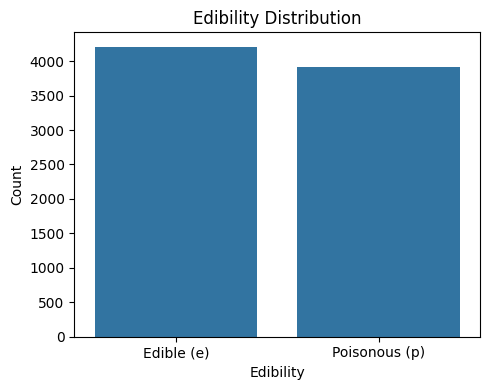

In [5]:
# distribution of edibility: 'e'=edible, 'p'=poisonous
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x='edibility', data=df_raw, order=['e', 'p'], ax=ax)
ax.set_xticklabels(['Edible (e)', 'Poisonous (p)'])
ax.set_title('Edibility Distribution')
ax.set_xlabel('Edibility')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

The dataset is reasonably balanced: slightly more edible samples than poisonous ones, but not dramatically skewed. Class imbalance won't be a major concern for this dataset.

/var/folders/xv/fhqprrpx67j8f7qsxqybcvcc0000gn/T/ipykernel_7567/3329444302.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(odor_order, rotation=30, ha='right')


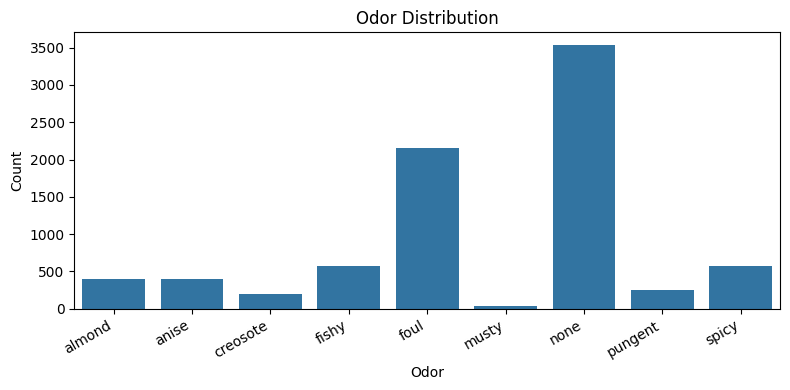

In [6]:
# distribution of odor: seaborn labels bars with the actual string values
odor_order = ['almond', 'anise', 'creosote', 'fishy', 'foul', 'musty', 'none', 'pungent', 'spicy']
# UCI encodes odors as single letters; map back to full names just for the plot
odor_name_map = {'a':'almond','l':'anise','c':'creosote','y':'fishy',
                 'f':'foul','m':'musty','n':'none','p':'pungent','s':'spicy'}
df_raw['odor_name'] = df_raw['odor'].map(odor_name_map)

fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(x='odor_name', data=df_raw, order=odor_order, ax=ax)
ax.set_xticklabels(odor_order, rotation=30, ha='right')
ax.set_title('Odor Distribution')
ax.set_xlabel('Odor')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

The majority of mushrooms have no odor (`none`) or a foul smell. The distribution is heavily skewed toward a few categories: `foul` and `none` dominate, while odors like creosote, musty, and pungent appear in only a small fraction of samples.

/var/folders/xv/fhqprrpx67j8f7qsxqybcvcc0000gn/T/ipykernel_7567/138681678.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Has bruises (t)', 'No bruises (f)'])


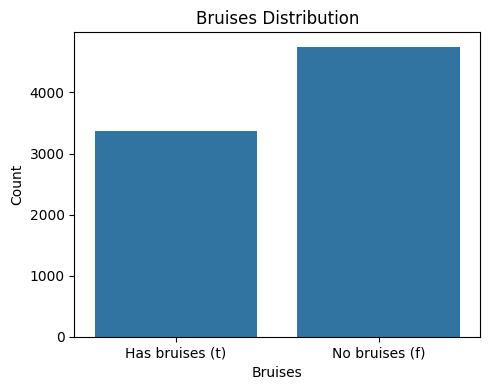

In [7]:
# distribution of bruises: 't'=has bruises, 'f'=no bruises
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x='bruises', data=df_raw, order=['t', 'f'], ax=ax)
ax.set_xticklabels(['Has bruises (t)', 'No bruises (f)'])
ax.set_title('Bruises Distribution')
ax.set_xlabel('Bruises')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

More mushrooms in this dataset lack bruises than have them, but it's not an extreme split: both classes are represented well enough to be informative as a potential predictor.

## Step 6: Feature vs. Edibility

Since both the feature and the target are categorical, a stripplot collapses all points onto two flat y-positions: not useful. 

A hue-colored countplot is better, showing how many mushrooms in each feature category are edible vs. poisonous as side-by-side bars, so the class separation is immediately visible.

/var/folders/xv/fhqprrpx67j8f7qsxqybcvcc0000gn/T/ipykernel_7567/3010322482.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(odor_order, rotation=30, ha='right')


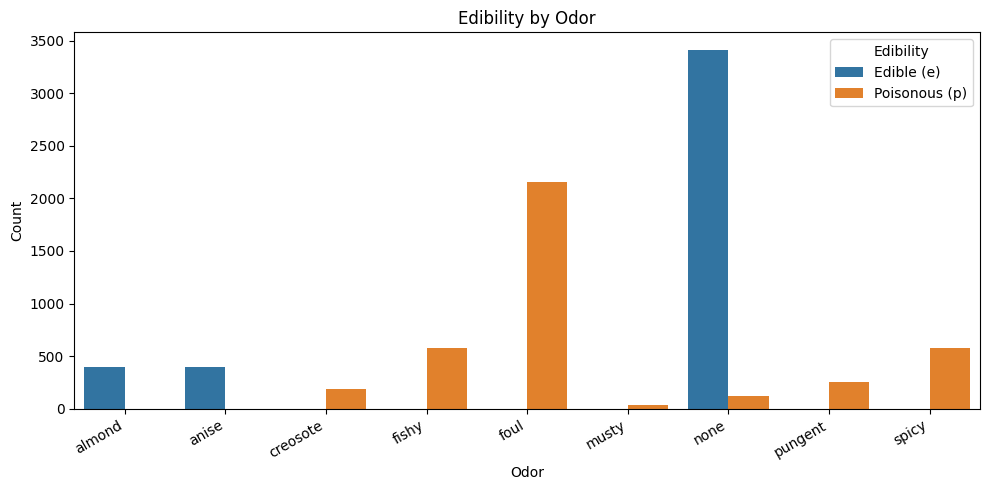

In [8]:
# edibility vs. odor: side-by-side bars per odor, colored by edibility
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(x='odor_name', hue='edibility', data=df_raw,
              order=odor_order, hue_order=['e', 'p'], ax=ax)
ax.set_xticklabels(odor_order, rotation=30, ha='right')
ax.set_title('Edibility by Odor')
ax.set_xlabel('Odor')
ax.set_ylabel('Count')
ax.legend(title='Edibility', labels=['Edible (e)', 'Poisonous (p)'])
plt.tight_layout()
plt.show()

/var/folders/xv/fhqprrpx67j8f7qsxqybcvcc0000gn/T/ipykernel_7567/1847763952.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Has bruises (t)', 'No bruises (f)'])


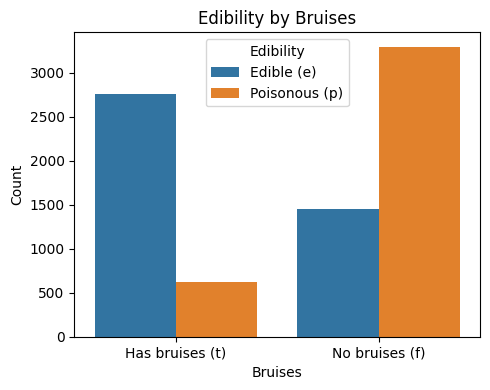

In [9]:
# edibility vs. bruises: side-by-side bars per bruises value, colored by edibility
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x='bruises', hue='edibility', data=df_raw,
              order=['t', 'f'], hue_order=['e', 'p'], ax=ax)
ax.set_xticklabels(['Has bruises (t)', 'No bruises (f)'])
ax.set_title('Edibility by Bruises')
ax.set_xlabel('Bruises')
ax.set_ylabel('Count')
ax.legend(title='Edibility', labels=['Edible (e)', 'Poisonous (p)'])
plt.tight_layout()
plt.show()

## Step 7: Preliminary Conclusions

**Odor as a predictor:**

The countplot makes odor look very strong with several odor categories appearing exclusively in one class. 

Almond and anise cluster entirely in the edible band, while creosote, fishy, foul, musty, pungent, and spicy cluster entirely in the poisonous band. Only mushrooms with no odor (`none`) show any real mix of both classes. 

That kind of near-perfect separation is a little too perfect. But still, a classifier that relies on odor would likely perform very well. 

(Whether that holds up in cross-validation is still to be determined, but this strongly suggests odor is worth including).

**Bruises as a predictor:**

The bruises plot is a little less clear. Both values, bruised and not bruised, contain a substantial mix of edible and poisonous samples. There's a visible skew. Bruised mushrooms seem to lean edible, and unbruised ones lean poisonous. The overlap is large enough that bruises alone wouldn't get you far. 

It's a plausible supporting feature, but not certain.

**Summary:**

Based on this EDA, odor is the standout candidate. It comes close to being a single-feature classifier on its own. Bruises adds some information, but wouldn't carry a model alone. 

A downstream classifier using both features would almost certainly be dominated by odor's contribution.